# Imports Needed

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Data Loading and Exploration

In [31]:
#Data Loading and Exploring
df = pd.read_csv('data/cleaned_data.csv')
df.head(5)

,reference,input,output,label,hallucination_type_realized,question_type,hallucination_type_encouraged
0,"A.D.A.M., Inc. estÃ¡ acreditada por la URAC, t...","What organization has accredited A.D.A.M., Inc...","A.D.A.M., Inc. is accredited by the Atlantis H...",hallucinated,Entity-error hallucination,Default question type,Entity-error hallucination
1,"""This dataset for NOAA's Science On a Sphere d...",What type of educational activity is encourage...,The dataset encourages learners to complete a ...,hallucinated,Relation-error hallucination,Default question type,Relation-error hallucination
2,"Dimension items include ""Foreground"" and ""Back...",What is the primary reason for a hit to be cla...,The primary reason for a hit to be classified ...,hallucinated,Relation-error hallucination,Other common hallucinated questions,Other hallucination
3,"Atlas Search runs a new process, called mongot...",What are the specific hardware requirements fo...,"Based on our production monitoring data, mongo...",hallucinated,Unverifiable information hallucination,Other common hallucinated questions,Other hallucination
4,The business implications are stark. In a surv...,What percentage of banking executives in the l...,34% of banking executives in the loan originat...,hallucinated,Relation-error hallucination,Other common hallucinated questions,Other hallucination


In [32]:
df.shape

(7820, 7)

In [33]:
df["label"].value_counts()

label
factual         5161
hallucinated    2659
Name: count, dtype: int64

<Axes: xlabel='label'>

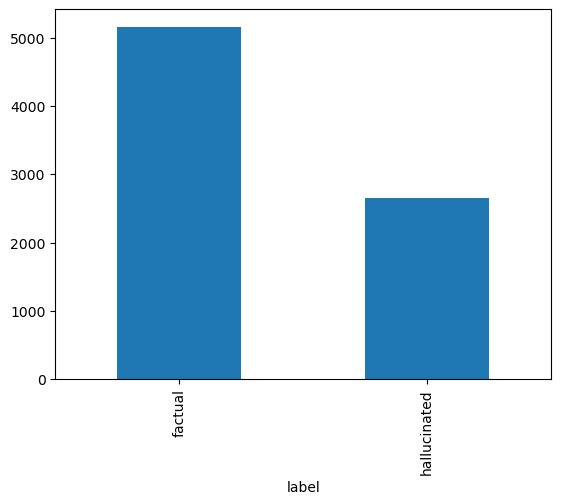

In [34]:
df["label"].value_counts().plot(kind="bar")

In [35]:
df.isnull().sum()

reference                           0
input                               0
output                              0
label                               0
hallucination_type_realized      5161
question_type                       0
hallucination_type_encouraged       0
dtype: int64

In [36]:
df["is_hallucination"] = (df["label"] == "hallucinated").astype(int)

### Hallucination Counts by Question Type

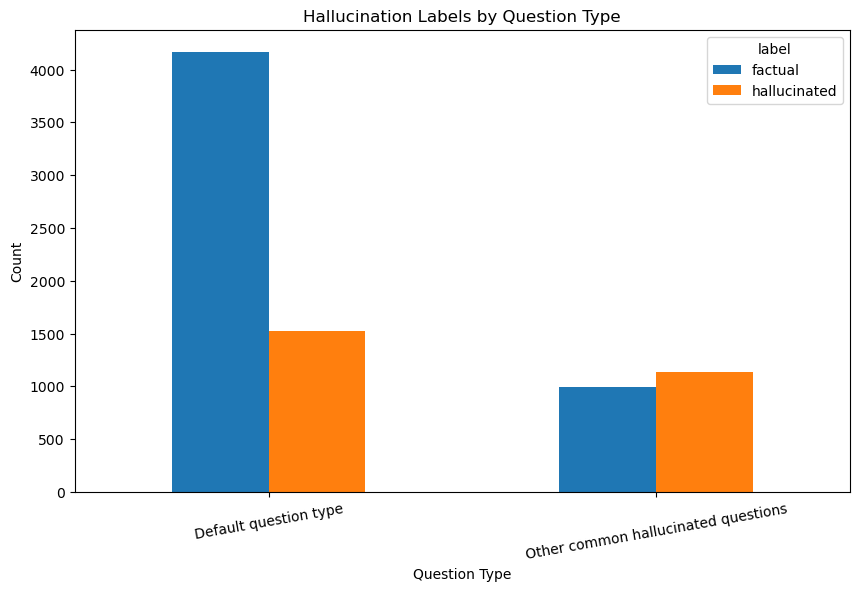

In [37]:
question_counts = pd.crosstab(
    df["question_type"],
    df["label"])

question_counts.plot(
    kind="bar",
    figsize=(10,6))

plt.title("Hallucination Labels by Question Type")

plt.xlabel("Question Type")
plt.ylabel("Count")

plt.xticks(rotation=10)

plt.show()

### Hallucination Types Count

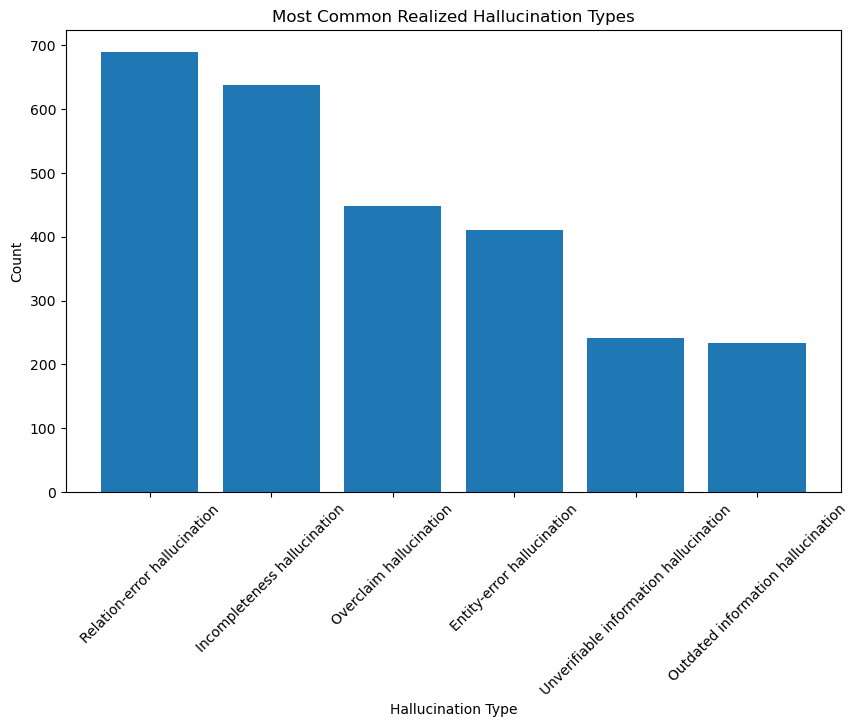

In [38]:
hallucination_counts = (df["hallucination_type_realized"].value_counts())

plt.figure(figsize=(10,6))

plt.bar(
    hallucination_counts.index,
    hallucination_counts.values
)

plt.title("Most Common Realized Hallucination Types")

plt.xlabel("Hallucination Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Hallucination Types Across Question Types

This graph could tell us which prompt/condition a specific hallucination type is more visible at and most likely occur.

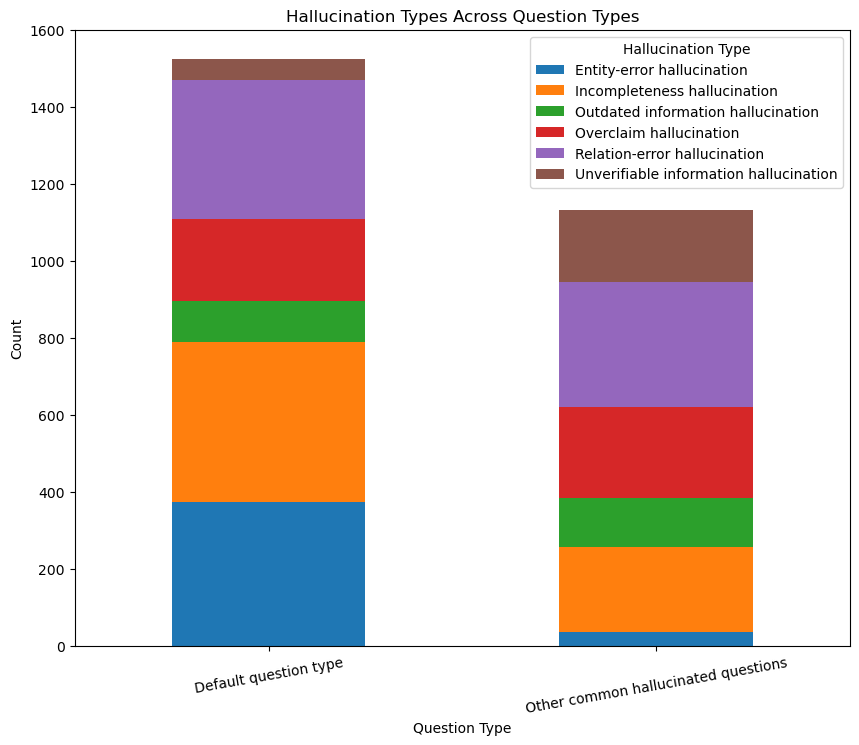

In [39]:
question_vs_hallucination = pd.crosstab(
    df["question_type"],
    df["hallucination_type_realized"]
)

question_vs_hallucination.plot(
    kind="bar",
    stacked=True,
    figsize=(10,8)
)

plt.title("Hallucination Types Across Question Types")

plt.xlabel("Question Type")
plt.ylabel("Count")

plt.xticks(rotation=10)

plt.legend(title="Hallucination Type",
           loc = "upper right")

plt.show()

### Heatmap of Hallucination Type Encouraged VS the Hallucination Type Realized

This is useful as it tells us the relationship between what kind of hallucination the prompt was designed to encourage vs what kind of hallucination the model actually produced. May tell us which hallucination types are easier to induce, etc.

Text(0, 0.5, 'Encouraged Hallucination Type')

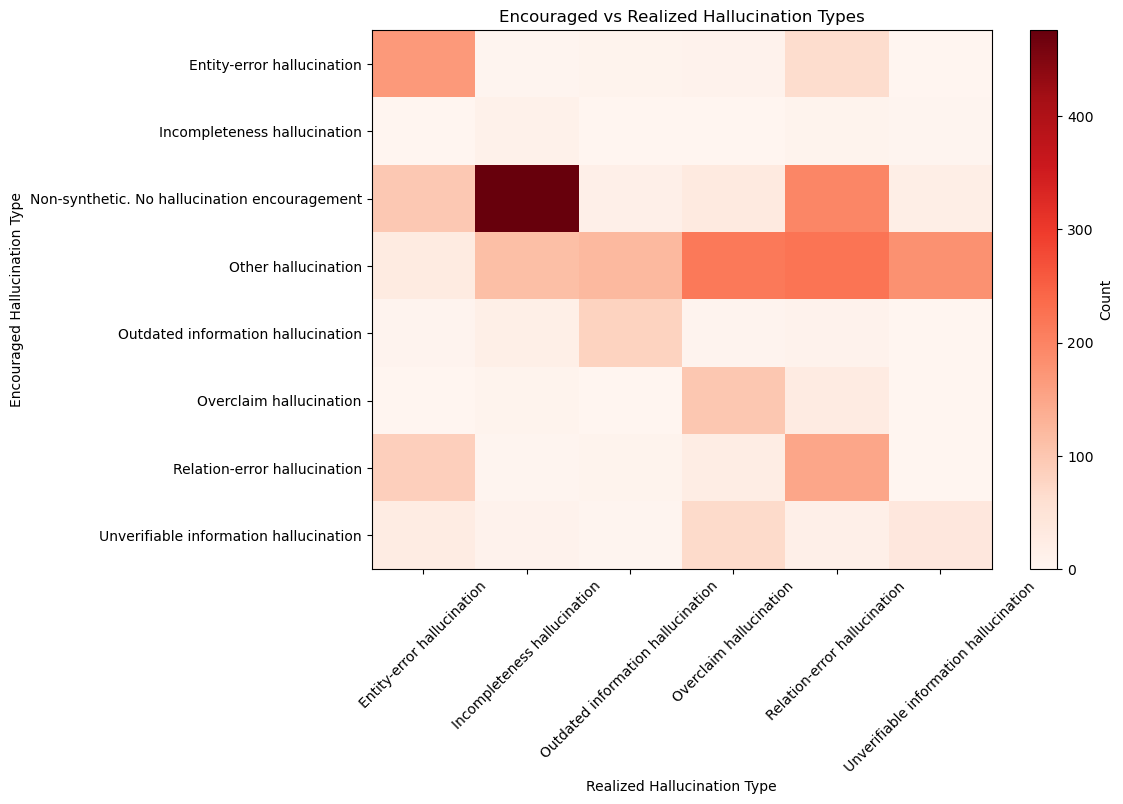

In [40]:
heatmap_data = pd.crosstab(
    df["hallucination_type_encouraged"],
    df["hallucination_type_realized"]
)

plt.figure(figsize=(10,7))

plt.imshow(heatmap_data, cmap='Reds', aspect='auto')

plt.colorbar(label='Count')

plt.xticks(
    range(len(heatmap_data.columns)),
    heatmap_data.columns,
    rotation=45
)

plt.yticks(
    range(len(heatmap_data.index)),
    heatmap_data.index
)

plt.title("Encouraged vs Realized Hallucination Types")
plt.xlabel("Realized Hallucination Type")
plt.ylabel("Encouraged Hallucination Type")